In [61]:
import pandas as pd
df = pd.read_csv("DATASET_RETAIL.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  1380 non-null   int64  
 1   Date            1380 non-null   str    
 2   Day             1380 non-null   str    
 3   Time            1380 non-null   str    
 4   Hour            1380 non-null   int64  
 5   Category        1380 non-null   str    
 6   Product         1380 non-null   str    
 7   Quantity        1380 non-null   int64  
 8   Unit_Price      1380 non-null   int64  
 9   Bill_Amount     1380 non-null   int64  
 10  Payment_Mode    1380 non-null   str    
 11  Customer_Type   1380 non-null   str    
 12  Discount        1380 non-null   int64  
 13  Final_Bill      1380 non-null   int64  
 14  Rating          1380 non-null   float64
 15  Is_Weekend      1380 non-null   str    
dtypes: float64(1), int64(7), str(8)
memory usage: 172.6 KB


In [62]:
df['Date'] = pd.to_datetime(df["Date"])
df['Time'] = pd.to_datetime(df["Time"], format = "%H:%M").dt.time

In [63]:
miss_values = df.isnull().sum()
print(f"Missing values:\n{miss_values}")

Missing values:
Transaction_ID    0
Date              0
Day               0
Time              0
Hour              0
Category          0
Product           0
Quantity          0
Unit_Price        0
Bill_Amount       0
Payment_Mode      0
Customer_Type     0
Discount          0
Final_Bill        0
Rating            0
Is_Weekend        0
dtype: int64


In [64]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows:\n{duplicates}")

Duplicate rows:
0


In [65]:

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Day']= pd.Categorical(df["Day"], categories = days, ordered = True)

In [66]:
df['Unit_Price'] = df['Unit_Price'].astype(float)
df['Bill_Amount'] = df['Bill_Amount'].astype(float)
df['Discount'] = df['Discount'].astype(float)
df['Final_Bill'] = df['Final_Bill'].astype(float)
print(df.dtypes)

Transaction_ID             int64
Date              datetime64[us]
Day                     category
Time                      object
Hour                       int64
Category                     str
Product                      str
Quantity                   int64
Unit_Price               float64
Bill_Amount              float64
Payment_Mode                 str
Customer_Type                str
Discount                 float64
Final_Bill               float64
Rating                   float64
Is_Weekend                   str
dtype: object


In [67]:
sales_by_day = df.groupby('Day')['Bill_Amount'].sum()
print(f"Sales by day:\n{sales_by_day}")

Sales by day:
Day
Monday       30375.0
Tuesday      43195.0
Wednesday    47450.0
Thursday     50025.0
Friday       59680.0
Saturday     37220.0
Sunday       73330.0
Name: Bill_Amount, dtype: float64


In [68]:
highest_sales_day = sales_by_day.idxmax()
highest_sales_amount = sales_by_day.max()
print(f"Highest sales day: {highest_sales_day} \namount: {highest_sales_amount}")

Highest sales day: Sunday 
amount: 73330.0


In [69]:
lowest_sales_day = sales_by_day.idxmin()
lowest_sales_amount = sales_by_day.min()
print(f"Lowest sales day: {lowest_sales_day} \namount: {lowest_sales_amount}")

Lowest sales day: Monday 
amount: 30375.0


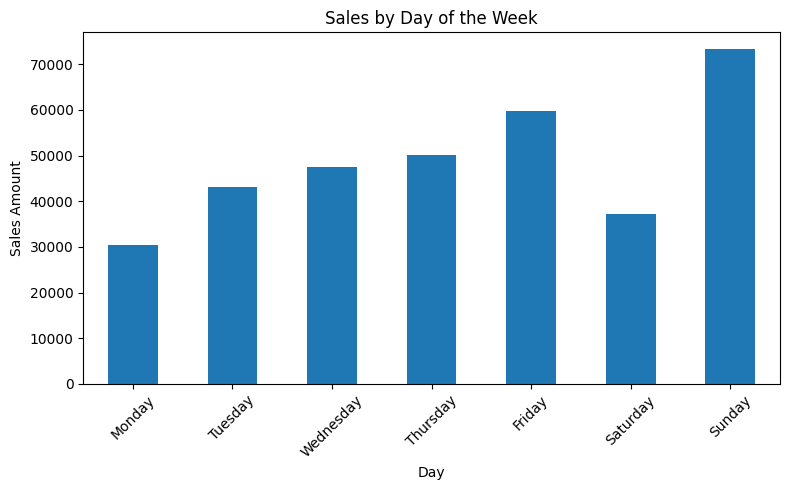

In [70]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sales_by_day.plot(kind='bar')
plt.title('Sales by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [71]:
slot = ['Morning', 'Late Morning', 'Afternoon', 'Evening', 'Night']
def get_time_slot(hour):
    if 6<= hour < 10:
        return slot[0]
    elif 10 <= hour < 14:
        return slot[1]
    elif 14 <= hour < 17:
        return slot[2]
    elif 17 <= hour < 21:
        return slot[3]
    else:
        return slot[4]

df['Time_Slot'] = df['Hour'].apply(get_time_slot)
df['Time_Slot']= pd.Categorical(df["Time_Slot"], categories = slot, ordered = True)

In [72]:
sales_by_time = df.groupby('Time_Slot')['Bill_Amount'].sum()
print(sales_by_time)
peak_time = sales_by_time.idxmax()
print("Peak Shopping Duration:", peak_time)

Time_Slot
Morning          21770.0
Late Morning     65475.0
Afternoon       155450.0
Evening          88920.0
Night             9660.0
Name: Bill_Amount, dtype: float64
Peak Shopping Duration: Afternoon


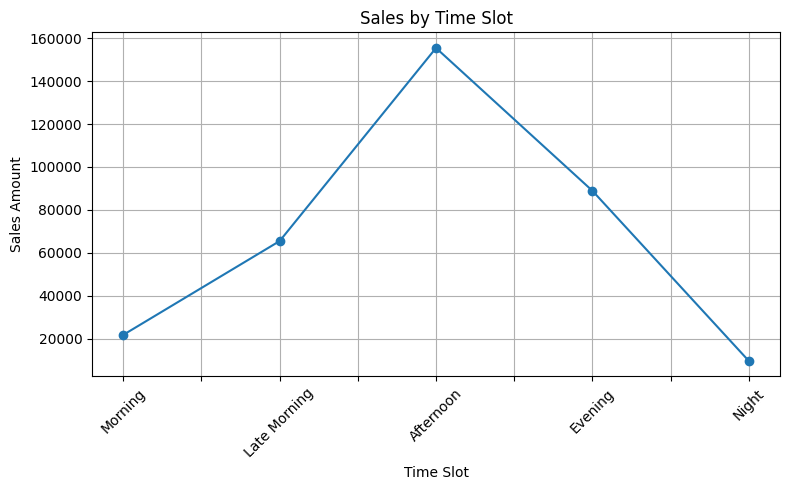

In [73]:
plt.figure(figsize=(8,5))
sales_by_time.plot(kind='line', marker='o')
plt.title('Sales by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

In [74]:
quantity_by_cat = df.groupby("Category")["Quantity"].sum()
best_cat = quantity_by_cat.idxmax() 
print("Best Selling Category :", best_cat)

Best Selling Category : Grocery


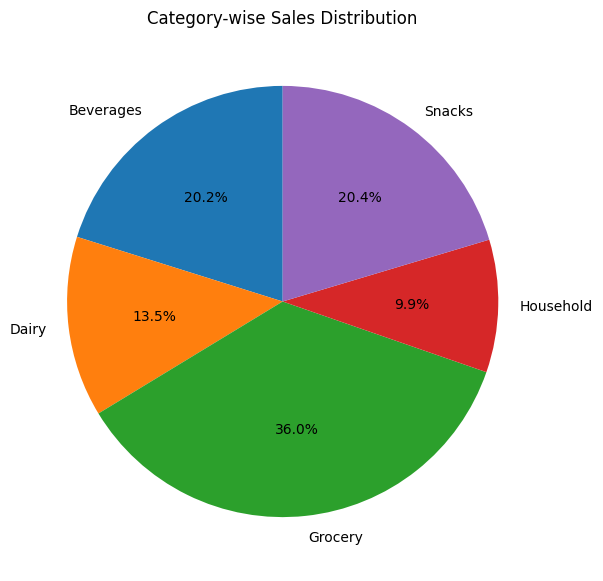

In [75]:
plt.figure(figsize=(7,7)) 
plt.pie(quantity_by_cat, labels=quantity_by_cat.index, autopct="%1.1f%%", startangle=90)
plt.title("Category-wise Sales Distribution") 
plt.show()

In [76]:
qty_by_product = df.groupby("Product")["Quantity"].sum() 
best_product = qty_by_product.idxmax()
print("Best Selling Product: ",best_product)

Best Selling Product:  Rice


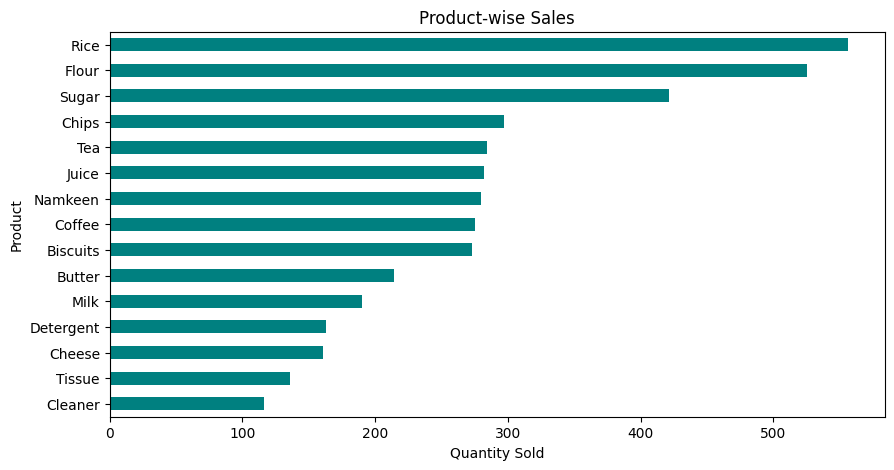

In [77]:
plt.figure(figsize=(10,5)) 
qty_by_product.sort_values().plot(kind="barh", color="teal" ) 
plt.title("Product-wise Sales") 
plt.xlabel("Quantity Sold") 
plt.ylabel("Product") 
plt.show()

<Axes: xlabel='Category'>

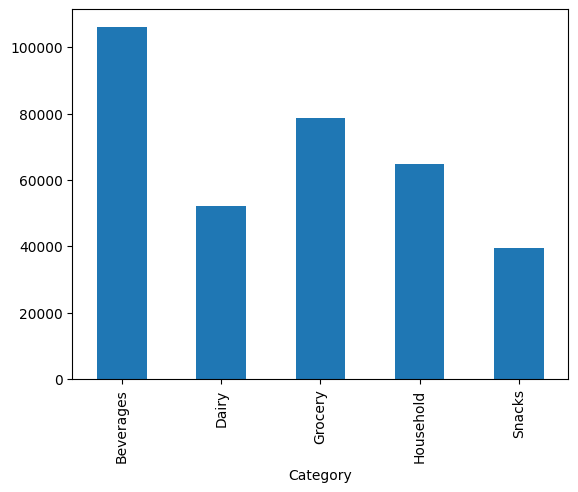

In [78]:
revenue_by_category=df.groupby("Category")["Bill_Amount"].sum() 
revenue_by_category.plot(kind="bar")

<Axes: xlabel='Product'>

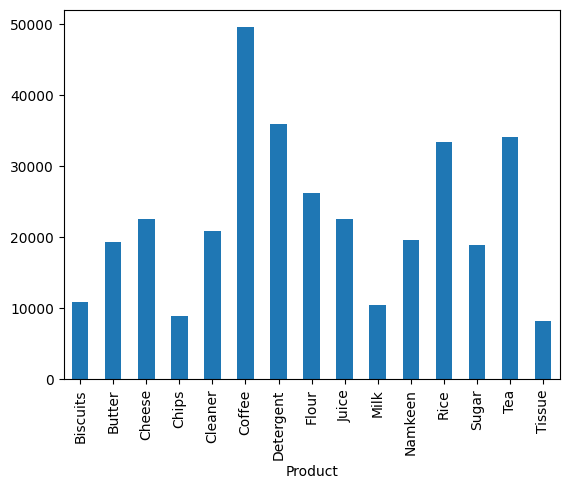

In [79]:
revenue_by_product=df.groupby("Product")["Bill_Amount"].sum()
revenue_by_product.plot(kind="bar")

In [80]:
avg_bill_amount = df["Bill_Amount"].mean() 
print("Average Bill Amount") 
print(f"₹{avg_bill_amount:.2f}")

Average Bill Amount
₹247.30


In [81]:
total_weekly_revenue = df["Bill_Amount"].sum() 
print("Total Weekly Revenue") 
print(f"₹{total_weekly_revenue:.2f}")

Total Weekly Revenue
₹341275.00


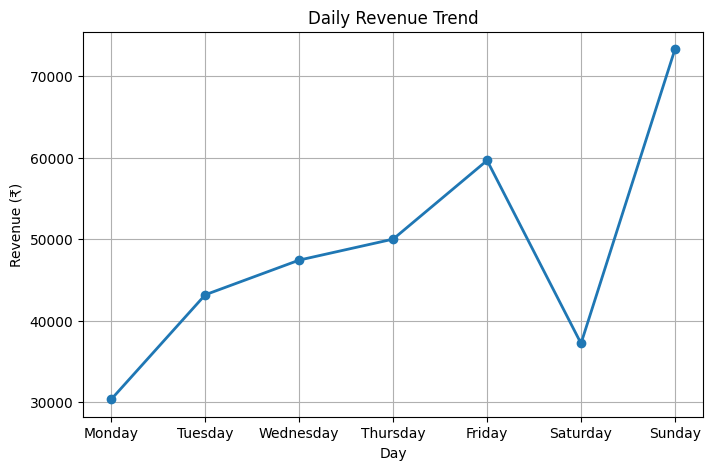

In [82]:
daily_revenue = df.groupby("Day")["Bill_Amount"].sum() 
plt.figure(figsize=(8,5)) 
daily_revenue.plot( kind="line", marker="o", linewidth=2 ) 
plt.title("Daily Revenue Trend")
plt.xlabel("Day") 
plt.ylabel("Revenue (₹)") 
plt.grid() 
plt.show()

In [83]:
avg_customer_rating = df["Rating"].mean() 
print("Average Customer Rating: ", round(avg_customer_rating, 2))

Average Customer Rating:  4.23


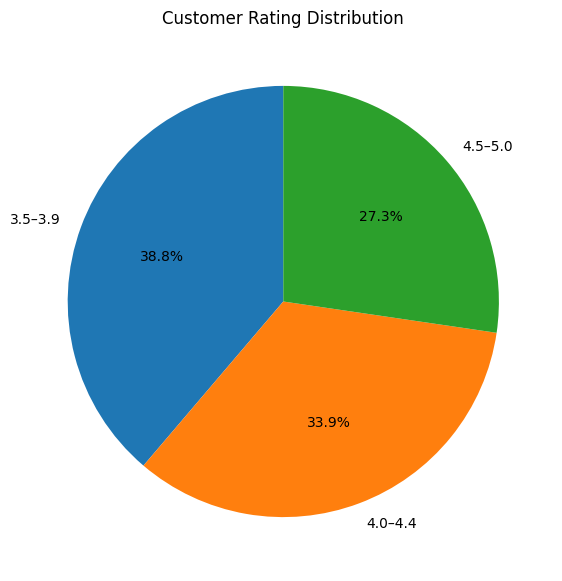

In [84]:
bins = [3.5, 4.0, 4.5, 5.0]
labels = ['3.5–3.9', '4.0–4.4', '4.5–5.0']

df["Rating_Bin"] = pd.cut(
    df["Rating"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
rating_distribution = df["Rating_Bin"].value_counts().sort_index() 

plt.figure(figsize=(7,7)) 
plt.pie( rating_distribution, labels=rating_distribution.index, autopct="%1.1f%%", startangle=90 ) 
plt.title("Customer Rating Distribution") 
plt.show()

In [85]:
pivot = pd.pivot_table( 
    df, 
    values="Bill_Amount", 
    index="Category", 
    columns="Payment_Mode", 
    aggfunc="sum" 
    ) 
print(pivot)

Payment_Mode     Card     Cash      UPI
Category                               
Beverages     25780.0  20540.0  59820.0
Dairy         15440.0  11420.0  25390.0
Grocery       19410.0  15525.0  43620.0
Household     22980.0   8440.0  33480.0
Snacks         7370.0   8080.0  23980.0


In [86]:
print("RETAIL STORE SALES DASHBOARD") 
print(f"Total Transactions     : {len(df)}") 
print(f"Total Revenue          : ₹{df['Bill_Amount'].sum():,.2f}") 
print(f"Average Bill           : ₹{df['Bill_Amount'].mean():.2f}") 
print(f"Highest Bill           : ₹{df['Bill_Amount'].max():.2f}") 
print(f"Lowest Bill            : ₹{df['Bill_Amount'].min():.2f}") 
print(f"Average Rating         : {df['Rating'].mean():.2f}") 
print(f"Total Discount Given   : ₹{df['Discount'].sum():,.2f}")

RETAIL STORE SALES DASHBOARD
Total Transactions     : 1380
Total Revenue          : ₹341,275.00
Average Bill           : ₹247.30
Highest Bill           : ₹1100.00
Lowest Bill            : ₹30.00
Average Rating         : 4.23
Total Discount Given   : ₹10,990.00


In [87]:
bins=[0,300,700,1500,5000] 
labels=["Low Spender","Medium Spender","High Spender","Premium Customer"] 
df["Customer_Segment"]=pd.cut( df["Bill_Amount"], bins=bins, labels=labels ) 
print(df["Customer_Segment"].value_counts())

Customer_Segment
Low Spender         1061
Medium Spender       243
High Spender          76
Premium Customer       0
Name: count, dtype: int64


<Axes: xlabel='Customer_Segment'>

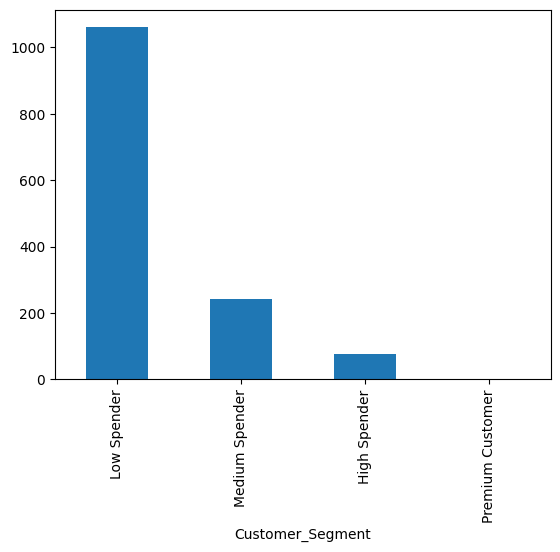

In [88]:
df["Customer_Segment"].value_counts().plot(kind="bar")

In [89]:
# ========================================================== 
# BUSINESS SUGGESTIONS MENU 
# # ========================================================== 
while True: 
    print("          BUSINESS SUGGESTIONS MENU") 
    print("1. Staff Management") 
    print("2. Sales Improvement") 
    print("3. Inventory Management") 
    print("4. Product Promotion") 
    print("5. Payment Recommendations") 
    print("6. Customer Satisfaction") 
    print("7. View All Suggestions") 
    print("8. Exit Suggestions Menu") 
    choice = int(input("Enter your choice: "))
    if choice == 1: 
        print("\nStaff Management") 
        print("• Increase staff on Sunday as it records the highest sales.") 
        print("• Open additional billing counters during peak shopping hours.") 
    elif choice == 2: 
        print("\nSales Improvement") 
        print("• Introduce Monday discounts to improve customer footfall.") 
        print("• Launch Saturday combo offers to increase weekend sales.") 
    elif choice == 3: 
        print("\nInventory Management") 
        print("• Maintain extra inventory from 2 PM to 5 PM.") 
        print(f"• Increase stock of '{best_product}' as it is the best-selling product.")
    elif choice == 4: 
        print("\nProduct Promotion") 
        print(f"• Promote the '{best_cat}' category using seasonal offers.") 
        print("• Bundle slow-selling products with popular products.") 
    elif choice == 5: 
        print("\nPayment Recommendations") 
        print("• Encourage UPI and Card payments.") 
        print("• Offer cashback and reward points on digital payments.") 
    elif choice == 6: 
        print("\nCustomer Satisfaction") 
        print("• Monitor customer ratings regularly.") 
        print("• Improve service quality and reduce billing waiting time.") 
    elif choice == 7: 
        print("\nALL BUSINESS SUGGESTIONS") 
        print("-"*60) 
        print("1. Increase staff on Sunday.") 
        print("2. Introduce Monday discount offers.") 
        print("3. Launch Saturday combo offers.") 
        print("4. Maintain additional inventory during 2 PM–5 PM.") 
        print(f"5. Increase stock of '{best_product}'.") 
        print(f"6. Promote the '{best_cat}' category.") 
        print("7. Encourage digital payments with cashback.") 
        print("8. Open additional billing counters during peak hours.") 
        print("9. Monitor customer ratings regularly.") 
        print("10. Forecast inventory using weekly sales trends.") 
    elif choice == 8: 
        print("\nReturning to Main Menu...") 
        break    
    else:        
        print("Invalid Choice! Please try again.")

          BUSINESS SUGGESTIONS MENU
1. Staff Management
2. Sales Improvement
3. Inventory Management
4. Product Promotion
5. Payment Recommendations
6. Customer Satisfaction
7. View All Suggestions
8. Exit Suggestions Menu

Returning to Main Menu...


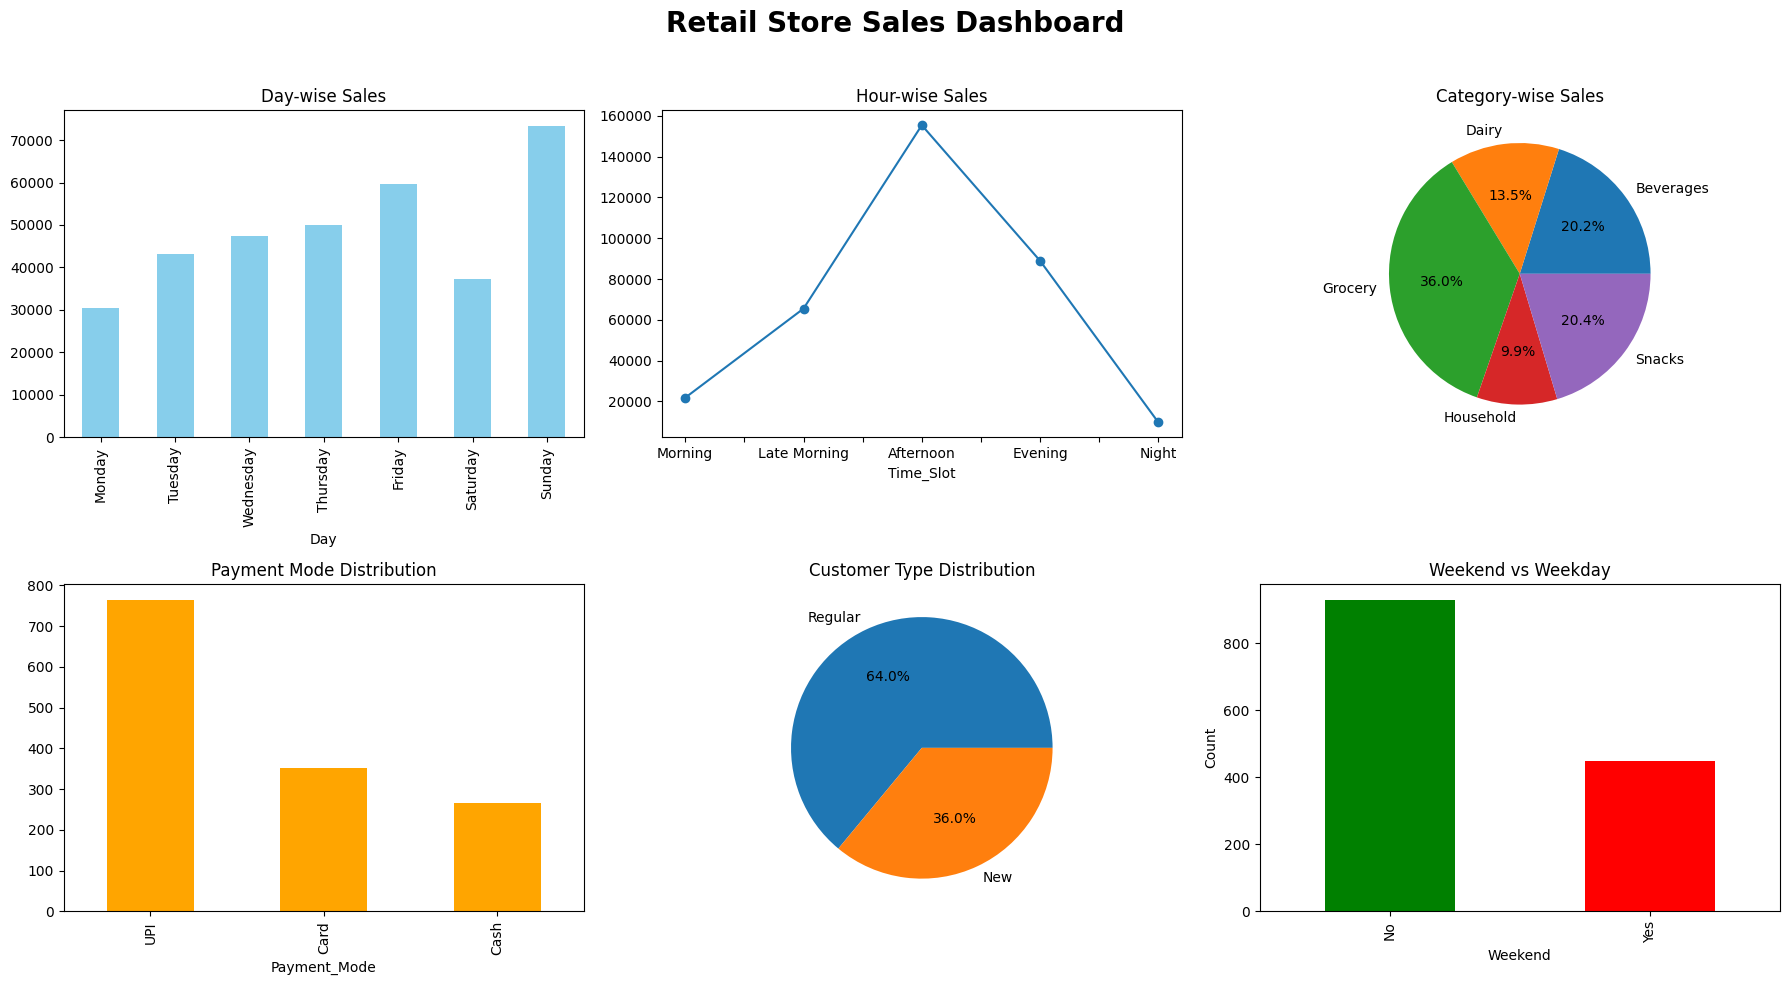

In [91]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    "Retail Store Sales Dashboard",
    fontsize=20,
    fontweight="bold"
)

# 1. Day-wise Sales
sales_by_day.plot(
    kind="bar",
    ax=axes[0, 0],
    color="skyblue",
    title="Day-wise Sales"
)

# 2. Hour-wise Sales
sales_by_time.plot(
    kind="line",
    ax=axes[0, 1],
    marker="o",
    title="Hour-wise Sales"
)

# 3. Category-wise Sales
quantity_by_cat.plot(
    kind="pie",
    ax=axes[0, 2],
    autopct="%1.1f%%"
)

axes[0, 2].set_ylabel("")
axes[0, 2].set_title("Category-wise Sales")

# 4. Payment Mode Distribution
payment_mode_count = df["Payment_Mode"].value_counts()
payment_mode_count.plot(
    kind="bar",
    ax=axes[1, 0],
    color="orange",
    title="Payment Mode Distribution"
)

# 5. Customer Type Distribution
customer_type = df["Customer_Type"].value_counts()
customer_type.plot(
    kind="pie",
    ax=axes[1, 1],
    autopct="%1.1f%%"
)

axes[1, 1].set_ylabel("")
axes[1, 1].set_title("Customer Type Distribution")

# 6. Weekend vs Weekday Sales
sales_by_week = df["Is_Weekend"].value_counts()
sales_by_week.plot(
    kind="bar",
    ax=axes[1, 2],
    color=["green", "red"],
    title="Weekend vs Weekday"
)

axes[1, 2].set_xlabel("Weekend")
axes[1, 2].set_ylabel("Count")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()